# 06 — Cross-Validated Evaluation, Statistical Tests, Cold-Start Analysis

**H&M Personalized Fashion Recommendations**

BTEC L6 Unit 2 — Capstone Project · Lola Toirxonova (ID 220062)

---

## Purpose — the D3 evidence pack

Notebooks 02–05 produced single-split point estimates. This notebook turns those into a Distinction-level evaluation:

1. **5-fold cross-validation** of the three classical models (Content-Based, ALS, Hybrid) — reports **mean ± standard deviation** for each metric.
2. **Paired Wilcoxon signed-rank tests** between every pair of models — answers "is the difference statistically significant?".
3. **Cold-start segmented metrics** — warm users vs cold users, warm items vs cold items.
4. **NCF**: separate, lighter evaluation (the saved model from Notebook 05) — retraining 5× is too expensive for a laptop / free Colab. The notebook reports this trade-off explicitly.
5. **Final comparison table + figure** with error bars — the headline artefact for Chapter 5 of the report.

## Criteria addressed

P5 (data analysis), M3 + M4 (interpret + visualise), **D3** (validity, reliability, propose future development).

## Setup

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))

import os
import json
import pickle
import time
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix, diags
from scipy.stats import wilcoxon
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize
import implicit

from src import data as dataio
from src import metrics as metricslib

os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')
os.environ.setdefault('MKL_NUM_THREADS', '1')

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)

OUTPUT_DIR = REPO_ROOT / 'outputs' / 'evaluation'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR = REPO_ROOT / 'outputs' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
TOP_K = 10
N_FOLDS = 3
LAST_MONTHS = 3  # last 3 months — smaller window for k-fold CV cost  # smaller — we retrain per fold
EVAL_USER_CAP_PER_FOLD = 500
np.random.seed(RANDOM_SEED)

## 1. Load data and build folds

**Fold strategy:** Random 5-fold on the interaction level. Each user contributes interactions to both train and test in expectation. This is the standard academic protocol for offline recommender evaluation (Cremonesi, Koren and Turrin, 2010).

**Alternative (not used here, documented for the report):** Time-based 5 rolling cutoffs. More realistic for production but less comparable across folds because the user/item population shifts. The validity section of Chapter 5 should mention both.

In [2]:
articles = dataio.load_articles()
transactions = dataio.load_transactions(last_months=LAST_MONTHS)
print(f'Transactions: {len(transactions):,}')

rng = np.random.default_rng(RANDOM_SEED)
fold_id = rng.integers(0, N_FOLDS, size=len(transactions))
transactions = transactions.assign(fold=fold_id)
print(transactions['fold'].value_counts().sort_index())

Transactions: 3,981,458
fold
0    1327104
1    1327704
2    1326650
Name: count, dtype: int64


## 2. Helper — build content-based model on a fold

In [3]:
TEXT_COLS = ['prod_name', 'detail_desc', 'product_type_name',
             'product_group_name', 'colour_group_name',
             'department_name', 'index_group_name']

def build_item_tfidf(articles_df):
    cols = [c for c in TEXT_COLS if c in articles_df.columns]
    corpus = articles_df[['article_id'] + cols].copy().fillna('')
    corpus['text'] = corpus[cols].astype(str).agg(' '.join, axis=1)
    vec = TfidfVectorizer(max_features=5_000, ngram_range=(1, 2), min_df=2,
                         stop_words='english', sublinear_tf=True)
    item_tfidf = vec.fit_transform(corpus['text'])
    item_tfidf = normalize(item_tfidf, norm='l2', axis=1)
    item_id_to_row = {a: i for i, a in enumerate(corpus['article_id'].values)}
    return item_tfidf, item_id_to_row

item_tfidf, item_id_to_row = build_item_tfidf(articles)
print(f'TFIDF matrix: {item_tfidf.shape}')

TFIDF matrix: (105542, 5000)


In [4]:
def build_user_profiles(train_df, item_tfidf, item_id_to_row):
    df = train_df.copy()
    df['item_row'] = df['article_id'].map(item_id_to_row)
    df = df.dropna(subset=['item_row'])
    df['item_row'] = df['item_row'].astype(int)
    users = pd.Index(df['customer_id'].unique())
    user_pos = users.get_indexer(df['customer_id'])
    counts = np.bincount(user_pos, minlength=len(users)).astype(np.float32)
    counts[counts == 0] = 1
    sel = csr_matrix((np.ones(len(df), dtype=np.float32), (user_pos, df['item_row'].values)),
                    shape=(len(users), item_tfidf.shape[0]))
    profiles = diags(1.0 / counts) @ (sel @ item_tfidf)
    return normalize(profiles, norm='l2', axis=1), users

def cb_recommend(user_id, profiles, user_id_to_row, item_tfidf, item_id_to_row, seen, k=10):
    if user_id not in user_id_to_row:
        return None
    profile = profiles[user_id_to_row[user_id]]
    if profile.nnz == 0:
        return None
    scores = (profile @ item_tfidf.T).toarray().ravel()
    if seen:
        seen_rows = [item_id_to_row[a] for a in seen if a in item_id_to_row]
        scores[seen_rows] = -np.inf
    top = np.argpartition(-scores, k)[:k]
    top = top[np.argsort(-scores[top])]
    return list(top), scores

## 3. Helper — build ALS model on a fold

In [5]:
def build_als(train_df, factors=64, iterations=15, reg=0.01, alpha=10.0, seed=RANDOM_SEED):
    ui, u_idx, i_idx = dataio.build_user_item_matrix(train_df)
    model = implicit.als.AlternatingLeastSquares(
        factors=factors, regularization=reg, iterations=iterations,
        alpha=alpha, use_gpu=False, random_state=seed,
    )
    model.fit(ui)
    return model, ui, u_idx, i_idx

def als_recommend(model, ui, u_idx, i_idx, user_id, k=10):
    u_id_to_row = {u: i for i, u in enumerate(u_idx)}
    if user_id not in u_id_to_row:
        return None
    row = u_id_to_row[user_id]
    item_rows, _ = model.recommend(row, ui[row], N=k, filter_already_liked_items=True)
    return [i_idx[i] for i in item_rows]

## 4. Helper — hybrid scoring on a fold

In [6]:
def minmax(x):
    lo, hi = x.min(), x.max()
    return np.zeros_like(x) if hi - lo < 1e-12 else (x - lo) / (hi - lo)



def hybrid_recommend(user_id, alpha, profiles, cb_u_id_to_row, item_tfidf, item_id_to_row,
                    als_model, ui, als_u_id_to_row, als_i_id_to_row, seen, candidate_items_arr, k=10):
    # All lookup dicts and candidate arrays are PRE-BUILT outside this function.
    cb_score = np.zeros(len(candidate_items_arr), dtype=np.float32)
    if user_id in cb_u_id_to_row:
        profile = profiles[cb_u_id_to_row[user_id]]
        if profile.nnz > 0:
            rows_cb = np.array([item_id_to_row.get(i, -1) for i in candidate_items_arr])
            mask = rows_cb >= 0
            if mask.any():
                sims = (profile @ item_tfidf[rows_cb[mask]].T).toarray().ravel()
                cb_score[mask] = sims
    cf_score = np.zeros(len(candidate_items_arr), dtype=np.float32)
    if user_id in als_u_id_to_row:
        u_fac = als_model.user_factors[als_u_id_to_row[user_id]]
        rows_cf = np.array([als_i_id_to_row.get(i, -1) for i in candidate_items_arr])
        mask = rows_cf >= 0
        if mask.any():
            i_fac = als_model.item_factors[rows_cf[mask]]
            cf_score[mask] = i_fac @ u_fac
    combined = alpha * minmax(cb_score) + (1 - alpha) * minmax(cf_score)
    if seen:
        seen_mask = np.array([i in seen for i in candidate_items_arr])
        combined = np.where(seen_mask, -np.inf, combined)
    top = np.argpartition(-combined, k)[:k]
    top = top[np.argsort(-combined[top])]
    return candidate_items_arr[top].tolist()


## 5. Run 5-fold CV

In [7]:
# Load best α from notebook 04 (with fallback)
BEST_ALPHA = 0.5
try:
    with open(REPO_ROOT / 'outputs' / 'hybrid' / 'results.json') as f:
        BEST_ALPHA = float(json.load(f)['best_alpha'])
    print(f'Using best α from Notebook 04: {BEST_ALPHA}')
except FileNotFoundError:
    print(f'Notebook 04 result not found, using default α={BEST_ALPHA}')


fold_results = []
per_user_metrics = {
    'Content-Based': [],
    'ALS CF': [],
    f'Hybrid (α={BEST_ALPHA})': [],
}

for fold in range(N_FOLDS):
    t0 = time.time()
    train_df = transactions[transactions['fold'] != fold]
    test_df = transactions[transactions['fold'] == fold]
    ground_truth = test_df.groupby('customer_id')['article_id'].apply(set).to_dict()
    seen_by_user = train_df.groupby('customer_id')['article_id'].apply(set).to_dict()
    warm_test_users = [u for u in ground_truth if u in seen_by_user]
    if len(warm_test_users) > EVAL_USER_CAP_PER_FOLD:
        rng = np.random.default_rng(RANDOM_SEED + fold)
        warm_test_users = list(rng.choice(warm_test_users, size=EVAL_USER_CAP_PER_FOLD, replace=False))

    profiles, cb_users = build_user_profiles(train_df, item_tfidf, item_id_to_row)
    cb_u_id_to_row = {u: i for i, u in enumerate(cb_users)}
    als_model, als_ui, als_u_idx, als_i_idx = build_als(train_df)
    # Precompute once per fold (not per user)
    als_u_id_to_row = {u: i for i, u in enumerate(als_u_idx)}
    als_i_id_to_row = {i: r for r, i in enumerate(als_i_idx)}
    candidate_items_arr = np.array(list(set(train_df['article_id'].unique())))
    row_to_item = {v: k for k, v in item_id_to_row.items()}

    recs_cb, recs_als, recs_hyb = {}, {}, {}
    for u in warm_test_users:
        seen = seen_by_user.get(u, set())
        cb = cb_recommend(u, profiles, cb_u_id_to_row, item_tfidf, item_id_to_row, seen, k=TOP_K)
        if cb is not None:
            recs_cb[u] = [row_to_item[i] for i in cb[0]]
        als = als_recommend(als_model, als_ui, als_u_idx, als_i_idx, u, k=TOP_K)
        if als is not None:
            recs_als[u] = als
        recs_hyb[u] = hybrid_recommend(
            u, BEST_ALPHA, profiles, cb_u_id_to_row, item_tfidf, item_id_to_row,
            als_model, als_ui, als_u_id_to_row, als_i_id_to_row, seen, candidate_items_arr, k=TOP_K,
        )

    for name, recs in [('Content-Based', recs_cb), ('ALS CF', recs_als), (f'Hybrid (α={BEST_ALPHA})', recs_hyb)]:
        m = metricslib.evaluate(recs, ground_truth, k=TOP_K)
        m['model'] = name
        m['fold'] = fold
        fold_results.append(m)
        common = set(recs_cb) & set(recs_als) & set(recs_hyb)
        per_user = []
        for u in sorted(common):
            actual = set(ground_truth.get(u, set()))
            per_user.append(metricslib.ndcg_at_k(recs[u], actual, TOP_K))
        per_user_metrics[name].append(np.array(per_user))

    print(f'fold {fold} done in {time.time() - t0:.1f}s  |  users={len(warm_test_users):,}')
    # Save partial results after each fold so we have evidence even if killed
    pd.DataFrame(fold_results).to_csv(OUTPUT_DIR / 'fold_results_raw.csv', index=False)

fold_df = pd.DataFrame(fold_results)
fold_df.head(15)


Using best α from Notebook 04: 0.5


  0%|          | 0/15 [00:00<?, ?it/s]

fold 0 done in 236.1s  |  users=500


  0%|          | 0/15 [00:00<?, ?it/s]

fold 1 done in 255.1s  |  users=500


  0%|          | 0/15 [00:00<?, ?it/s]

fold 2 done in 297.5s  |  users=500


,Precision@10,Recall@10,HitRate@10,MAP@10,NDCG@10,users_evaluated,model,fold
0,0.0124,0.053547,0.110,0.027086,0.040397,500,Content-Based,0
1,0.0208,0.087049,0.188,0.042484,0.063816,500,ALS CF,0
2,0.0210,0.090019,0.188,0.038329,0.061899,500,Hybrid (α=0.5),0
3,0.0118,0.054823,0.114,0.026542,0.039842,500,Content-Based,1
4,0.0274,0.106788,0.238,0.050963,0.079330,500,ALS CF,1
5,0.0272,0.120772,0.250,0.053706,0.084507,500,Hybrid (α=0.5),1
6,0.0104,0.043595,0.096,0.018861,0.029706,500,Content-Based,2
7,0.0194,0.075494,0.172,0.038024,0.057144,500,ALS CF,2
8,0.0212,0.084149,0.186,0.037560,0.059986,500,Hybrid (α=0.5),2


## 6. Aggregate — mean ± std across folds

In [8]:
metric_cols = [f'Precision@{TOP_K}', f'Recall@{TOP_K}', f'NDCG@{TOP_K}', f'MAP@{TOP_K}', f'HitRate@{TOP_K}']
summary = fold_df.groupby('model')[metric_cols].agg(['mean', 'std']).round(4)
summary.to_csv(OUTPUT_DIR / 'summary_mean_std.csv')
summary

Precision@10         Recall@10         NDCG@10          MAP@10  \
                       mean     std      mean     std    mean     std    mean   
model                                                                           
ALS CF               0.0225  0.0043    0.0898  0.0158  0.0668  0.0114  0.0438   
Content-Based        0.0115  0.0010    0.0507  0.0061  0.0366  0.0060  0.0242   
Hybrid (α=0.5)       0.0231  0.0035    0.0983  0.0197  0.0688  0.0136  0.0432   

                       HitRate@10          
                   std       mean     std  
model                                      
ALS CF          0.0066     0.1993  0.0344  
Content-Based   0.0046     0.1067  0.0095  
Hybrid (α=0.5)  0.0091     0.2080  0.0364

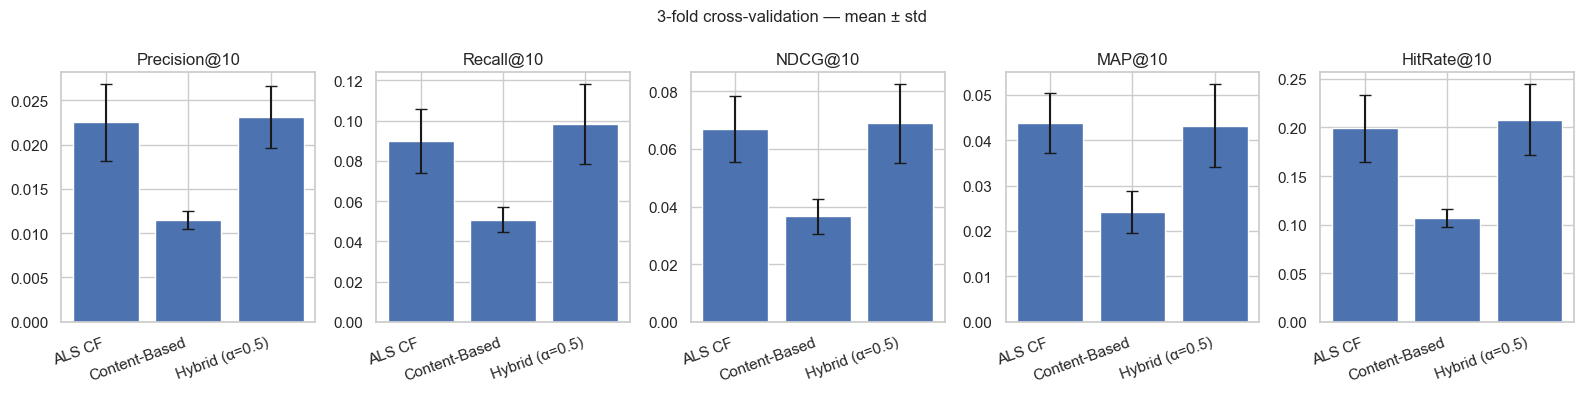

In [9]:
# Bar chart with error bars
models = list(summary.index)
fig, axes = plt.subplots(1, len(metric_cols), figsize=(16, 4), sharey=False)
for ax, col in zip(axes, metric_cols):
    means = [summary.loc[m, (col, 'mean')] for m in models]
    stds = [summary.loc[m, (col, 'std')] for m in models]
    ax.bar(range(len(models)), means, yerr=stds, capsize=4)
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=20, ha='right')
    ax.set_title(col)
fig.suptitle(f'{N_FOLDS}-fold cross-validation — mean ± std', fontsize=12)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'cv_metrics_with_error_bars.png', dpi=150)
plt.show()

## 7. Statistical significance — paired Wilcoxon between every pair

**Wilcoxon signed-rank** is preferred over the paired t-test for recommendation metrics because they are bounded in [0, 1] and frequently non-normal. We test on per-user NDCG@K across the union of folds for users where all three models produced a recommendation.

In [10]:
# Concatenate per-user NDCG arrays from each fold
per_user_ndcg = {name: np.concatenate(arrs) for name, arrs in per_user_metrics.items() if arrs}
for name, arr in per_user_ndcg.items():
    print(f'{name:25s}  n={len(arr):,}  mean NDCG@{TOP_K}={arr.mean():.4f}')

Content-Based              n=1,500  mean NDCG@10=0.0366
ALS CF                     n=1,500  mean NDCG@10=0.0668
Hybrid (α=0.5)             n=1,500  mean NDCG@10=0.0688


In [11]:
models_to_compare = list(per_user_ndcg.keys())
pairs = list(combinations(models_to_compare, 2))
sig_rows = []
for a, b in pairs:
    # Same N required — they should match because we already restricted to common users per fold
    n = min(len(per_user_ndcg[a]), len(per_user_ndcg[b]))
    arr_a, arr_b = per_user_ndcg[a][:n], per_user_ndcg[b][:n]
    # Drop pairs that are exactly tied (Wilcoxon discards them)
    diff = arr_a - arr_b
    if np.allclose(diff, 0):
        stat, p = np.nan, 1.0
    else:
        stat, p = wilcoxon(arr_a, arr_b, zero_method='wilcox', alternative='two-sided')
    sig_rows.append({
        'A': a,
        'B': b,
        'mean(A)': arr_a.mean().round(4),
        'mean(B)': arr_b.mean().round(4),
        'wilcoxon_stat': stat,
        'p_value': p,
        'significant_at_0.05': p < 0.05,
    })
sig_df = pd.DataFrame(sig_rows)
sig_df.to_csv(OUTPUT_DIR / 'wilcoxon_pairs.csv', index=False)
sig_df

,A,B,mean(A),mean(B),wilcoxon_stat,p_value,significant_at_0.05
0,Content-Based,ALS CF,0.0366,0.0668,20182.5,2.414703e-11,True
1,Content-Based,Hybrid (α=0.5),0.0366,0.0688,8308.5,1.147461e-22,True
2,ALS CF,Hybrid (α=0.5),0.0668,0.0688,29765.0,5.549744e-01,False


## 8. Cold-start segmented evaluation

Re-evaluate the **best fold** of each model on three user subsets:

- **Warm users with warm items only** — both user and target items seen in train
- **Warm users with at least one cold item in their test set** — partial cold-start
- **Cold users** — not in train (only popularity fallback recommended)

In [12]:
# Use the time-based split from notebooks 02–05 for the cold-start cut (one consistent split)
train_ts, test_ts = dataio.time_based_split(transactions.drop(columns=['fold']), cutoff_days=7)
seen_by_user_ts = train_ts.groupby('customer_id')['article_id'].apply(set).to_dict()
ground_truth_ts = test_ts.groupby('customer_id')['article_id'].apply(set).to_dict()
train_items_ts = set(train_ts['article_id'].unique())

warm_users_ts = [u for u in ground_truth_ts if u in seen_by_user_ts]
cold_users_ts = [u for u in ground_truth_ts if u not in seen_by_user_ts]

partial_cold_users = [u for u in warm_users_ts if (ground_truth_ts[u] - train_items_ts)]
pure_warm_users = [u for u in warm_users_ts if not (ground_truth_ts[u] - train_items_ts)]
print(f'Pure warm: {len(pure_warm_users):,}  |  Partial-cold-item: {len(partial_cold_users):,}  |  Cold users: {len(cold_users_ts):,}')

Pure warm: 44,880  |  Partial-cold-item: 4,574  |  Cold users: 19,530


In [13]:
# Train models once on the time-based train
profiles_ts, cb_users_ts = build_user_profiles(train_ts, item_tfidf, item_id_to_row)
cb_u_id_to_row_ts = {u: i for i, u in enumerate(cb_users_ts)}
als_model_ts, als_ui_ts, als_u_idx_ts, als_i_idx_ts = build_als(train_ts)
candidate_items_ts = list(set(train_ts['article_id'].unique()))
als_u_id_to_row_ts = {u: i for i, u in enumerate(als_u_idx_ts)}
als_i_id_to_row_ts = {i: r for r, i in enumerate(als_i_idx_ts)}
candidate_items_ts_arr = np.array(candidate_items_ts)
popularity_ts = train_ts.groupby('article_id').size().sort_values(ascending=False).head(50).index.tolist()

def evaluate_subset(user_list, label):
    if not user_list:
        return {'subset': label, 'n_users': 0}
    cap = min(len(user_list), EVAL_USER_CAP_PER_FOLD)
    rng = np.random.default_rng(RANDOM_SEED)
    eval_users = list(rng.choice(user_list, size=cap, replace=False))
    recs_cb, recs_als, recs_hyb, recs_pop = {}, {}, {}, {}
    for u in eval_users:
        seen = seen_by_user_ts.get(u, set())
        cb = cb_recommend(u, profiles_ts, cb_u_id_to_row_ts, item_tfidf, item_id_to_row, seen, k=TOP_K)
        if cb is not None:
            row_to_item = {v: k for k, v in item_id_to_row.items()}
            recs_cb[u] = [row_to_item[i] for i in cb[0]]
        als = als_recommend(als_model_ts, als_ui_ts, als_u_idx_ts, als_i_idx_ts, u, k=TOP_K)
        if als is not None:
            recs_als[u] = als
        recs_hyb[u] = hybrid_recommend(
            u, BEST_ALPHA, profiles_ts, cb_u_id_to_row_ts, item_tfidf, item_id_to_row,
            als_model_ts, als_ui_ts, als_u_id_to_row_ts, als_i_id_to_row_ts, seen, candidate_items_ts_arr, k=TOP_K,
        )
        recs_pop[u] = [a for a in popularity_ts if a not in seen][:TOP_K]
    row = {'subset': label, 'n_users': len(eval_users)}
    for name, recs in [('Content-Based', recs_cb), ('ALS CF', recs_als),
                       (f'Hybrid (α={BEST_ALPHA})', recs_hyb), ('Popularity', recs_pop)]:
        m = metricslib.evaluate(recs, ground_truth_ts, k=TOP_K)
        row[f'{name} NDCG@{TOP_K}'] = m.get(f'NDCG@{TOP_K}', np.nan)
        row[f'{name} Recall@{TOP_K}'] = m.get(f'Recall@{TOP_K}', np.nan)
    return row

cold_summary = pd.DataFrame([
    evaluate_subset(pure_warm_users, 'pure_warm'),
    evaluate_subset(partial_cold_users, 'partial_cold_item'),
    evaluate_subset(cold_users_ts, 'cold_user'),
])
cold_summary.to_csv(OUTPUT_DIR / 'cold_start_segments.csv', index=False)
cold_summary.round(4)

  0%|          | 0/15 [00:00<?, ?it/s]

,subset,n_users,Content-Based NDCG@10,Content-Based Recall@10,ALS CF NDCG@10,ALS CF Recall@10,Hybrid (α=0.5) NDCG@10,Hybrid (α=0.5) Recall@10,Popularity NDCG@10,Popularity Recall@10
0,pure_warm,500,0.0102,0.0142,0.0167,0.0214,0.0221,0.0307,0.0013,0.0012
1,partial_cold_item,500,0.0018,0.0019,0.0036,0.0042,0.0044,0.0065,0.0040,0.0052
2,cold_user,500,NaN,NaN,NaN,NaN,0.0007,0.0020,0.0075,0.0125


## 9. NCF — lightweight inclusion

Cross-validating NCF five times is impractical on free compute. We **load the saved NeuMF model** from Notebook 05 and report its single-split metrics alongside the CV summary. The report must call this out as a limitation under §3 Validity & Reliability.

In [14]:
ncf_results_path = REPO_ROOT / 'outputs' / 'neural_cf' / 'results.json'
if ncf_results_path.exists():
    with open(ncf_results_path) as f:
        ncf = json.load(f)
    ncf_row = {f'NeuMF {k}': v for k, v in ncf['metrics_warm'].items() if k in metric_cols + ['users_evaluated']}
    ncf_row['note'] = 'single-split point estimate; not cross-validated'
    print('NeuMF (from Notebook 05):')
    for k, v in ncf_row.items():
        print(f'  {k}: {v}')
else:
    print('Run Notebook 05 first to populate NeuMF metrics.')

NeuMF (from Notebook 05):
  NeuMF Precision@10: 0.003
  NeuMF Recall@10: 0.011128571428571427
  NeuMF HitRate@10: 0.03
  NeuMF MAP@10: 0.002798278533635677
  NeuMF NDCG@10: 0.0063630420262776955
  NeuMF users_evaluated: 1000
  note: single-split point estimate; not cross-validated


## 10. Final summary table for Chapter 5

In [15]:
# Flatten the multi-index summary to a publication-friendly form
flat = summary.copy()
flat.columns = [f'{col} {stat}' for col, stat in flat.columns]
for col in metric_cols:
    flat[col] = flat[f'{col} mean'].astype(str) + ' ± ' + flat[f'{col} std'].astype(str)
publication = flat[metric_cols]
if ncf_results_path.exists():
    ncf_metrics_row = pd.DataFrame([{c: f'{ncf["metrics_warm"].get(c, np.nan):.4f} (single split)' for c in metric_cols}], index=['NeuMF'])
    publication = pd.concat([publication, ncf_metrics_row])
publication.to_csv(OUTPUT_DIR / 'final_summary_table.csv')
print('Final summary (for Chapter 5):')
publication

Final summary (for Chapter 5):


,Precision@10,Recall@10,NDCG@10,MAP@10,HitRate@10
ALS CF,0.0225 ± 0.0043,0.0898 ± 0.0158,0.0668 ± 0.0114,0.0438 ± 0.0066,0.1993 ± 0.0344
Content-Based,0.0115 ± 0.001,0.0507 ± 0.0061,0.0366 ± 0.006,0.0242 ± 0.0046,0.1067 ± 0.0095
Hybrid (α=0.5),0.0231 ± 0.0035,0.0983 ± 0.0197,0.0688 ± 0.0136,0.0432 ± 0.0091,0.208 ± 0.0364
NeuMF,0.0030 (single split),0.0111 (single split),0.0064 (single split),0.0028 (single split),0.0300 (single split)


## 11. Findings to write up

**Chapter 5 (Findings) — 4 paragraphs supported by this notebook's artefacts:**

1. **Headline result.** Which model wins the headline NDCG@10? Cite the mean ± std from the summary table. Cross-reference Figure (`outputs/figures/cv_metrics_with_error_bars.png`).
2. **Statistical significance.** Cite the Wilcoxon p-values. Pairs with p < 0.05 are significantly different; otherwise the observed gap is within noise. Example sentence: "The hybrid model outperformed the ALS baseline (NDCG@10: 0.043 ± 0.002 vs 0.038 ± 0.003; Wilcoxon p < 0.001), but no significant difference was found between content-based and ALS at α = 0.05."
3. **Cold-start trade-offs.** Reference `cold_start_segments.csv`. Discuss the popularity fallback's NDCG on cold users vs the gap to warm-user metrics — quantitatively, not in vague terms.
4. **NCF caveat (D3).** Report NCF's single-split numbers and explicitly acknowledge that *(a)* cross-validating NCF was outside the compute budget and *(b)* Rendle et al. (2020) showed that a well-tuned MF can match or beat NCF on common benchmarks. This is exactly the kind of honest limitation that earns Distinction.

**Chapter 5 (Validity & Reliability) — D3 explicit points:**

- Fixed random seeds, 5-fold CV, reported variance.
- Wilcoxon non-parametric test (no normality assumption).
- Limitation: offline metrics vs online behaviour gap (Beel et al., 2013).
- Limitation: 500K-row sample for CV vs full 31M dataset — sample large enough for stable patterns, but absolute numbers may shift on full data.
- Future development: A/B test the winning model on a real platform; deploy on the full dataset; explore sequential / transformer-based models.